# LOAN APPROVAL PREDICTION

**Problem Statement:** Predict whether loan will be approved or rejected.

**Dataset:** Loan Approval Dataset ( Keggle Link : https://www.kaggle.com/datasets/architsharma01/loan-approval-prediction-dataset )

This notebook demonstrates the full project structure:
1. EDA
2. Cleaning & Preprocessing
3. Train Multiple ML models
4. Compare models using metrics
5. Select & justify the best model
6. Hyper-Parameter Tuning the Best Model
7. Predict on unseen data

## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import LabelEncoder,OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score,accuracy_score,recall_score,precision_score,confusion_matrix,classification_report,roc_auc_score

## 2. Load Dataset

In [ ]:
df = pd.read_csv('../datasets/loan_approval_dataset.csv')
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


## 3. Data Preperation

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


Here, `loan_id` doesnot mean anything so we can simply drop it.

In [369]:
df.describe().round(2)

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.0,4269.0,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00
mean,2135.0,2.5,5059123.92,15133450.46,10.90,599.94,7472616.54,4973155.31,15126305.93,4976692.43
std,1232.5,1.7,2806839.83,9043362.98,5.71,172.43,6503636.59,4388966.09,9103753.67,3250185.31
min,1.0,0.0,200000.00,300000.00,2.00,300.00,-100000.00,0.00,300000.00,0.00
25%,1068.0,1.0,2700000.00,7700000.00,6.00,453.00,2200000.00,1300000.00,7500000.00,2300000.00
50%,2135.0,3.0,5100000.00,14500000.00,10.00,600.00,5600000.00,3700000.00,14600000.00,4600000.00
75%,3202.0,4.0,7500000.00,21500000.00,16.00,748.00,11300000.00,7600000.00,21700000.00,7100000.00
max,4269.0,5.0,9900000.00,39500000.00,20.00,900.00,29100000.00,19400000.00,39200000.00,14700000.00


In [370]:
df.describe(include=['object'])

,education,self_employed,loan_status
count,4269,4269,4269
unique,2,2,2
top,Graduate,Yes,Approved
freq,2144,2150,2656


In [371]:
df.shape

(4269, 13)

In [372]:
df.isnull().sum()

loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64

In [373]:
df.duplicated().sum()

np.int64(0)

In [374]:
df = df.drop('loan_id',axis=1)
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


WE ARE TRYING TO PREDICT LOAN STATUS, SO OUR TARGET COLUMN IS `loan_status`.

In [375]:
df.columns

Index([' no_of_dependents', ' education', ' self_employed', ' income_annum',
       ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='object')

Here, the column nmaes have space as the first letter. We need to fix it.

In [376]:
df.columns = df.columns.str.strip()
df.columns

Index(['no_of_dependents', 'education', 'self_employed', 'income_annum',
       'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value',
       'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value',
       'loan_status'],
      dtype='object')

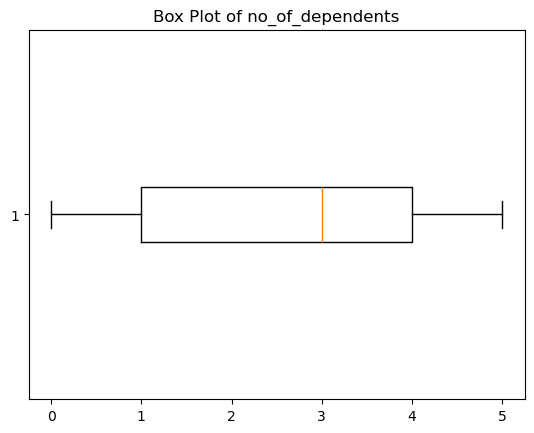

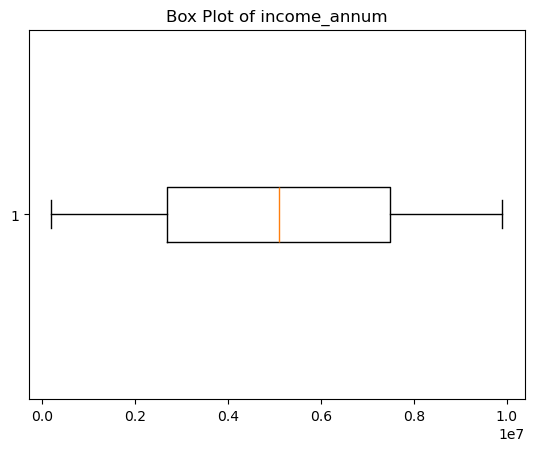

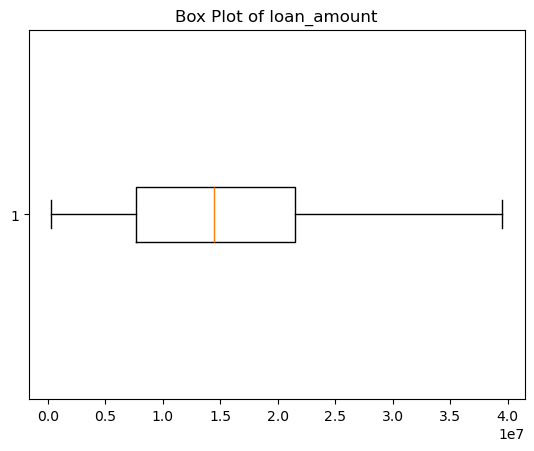

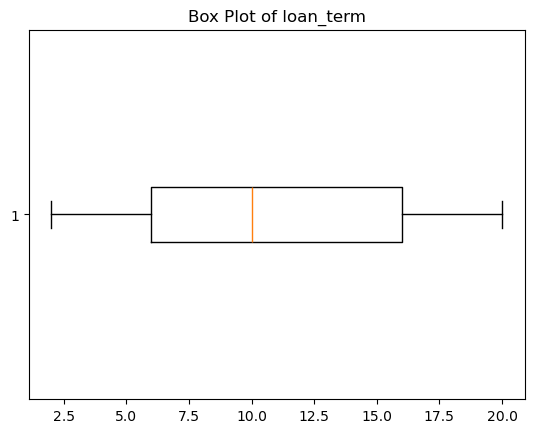

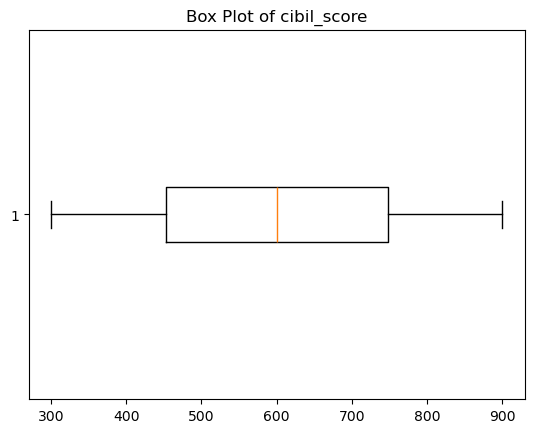

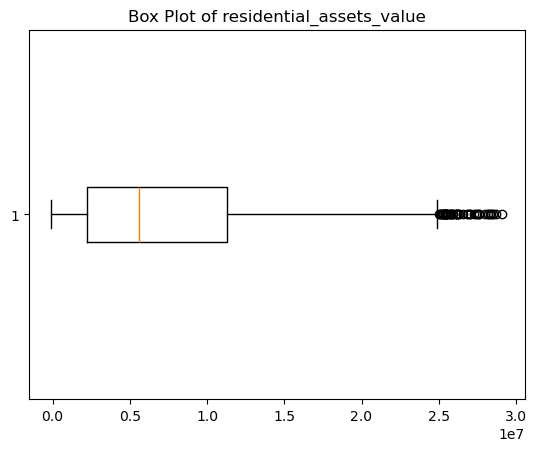

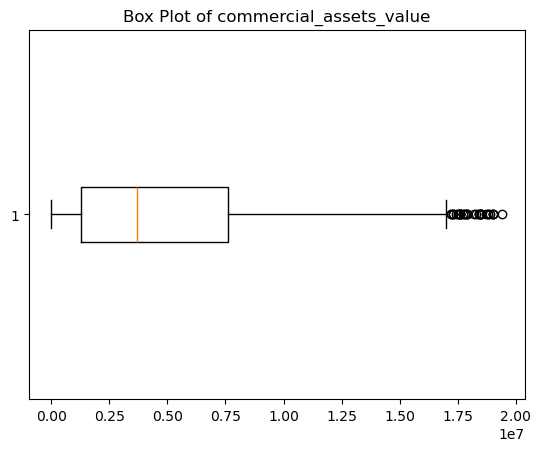

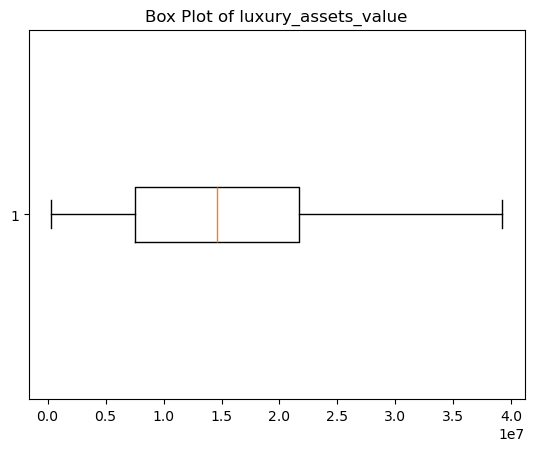

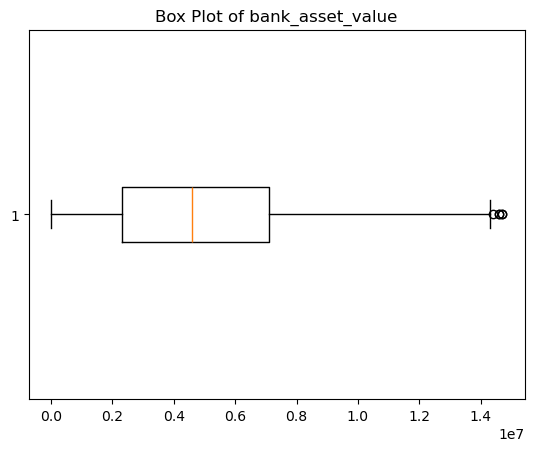

In [377]:
# Checking for Outliers.
num_cols = df.select_dtypes(exclude=['object']).columns
for c in num_cols:
    plt.boxplot(df[c],vert=False)
    plt.title(f"Box Plot of {c}")
    plt.show()


Since some people can have the assets of very high value, we will not handle outlires of asets_value columns. Other column doesnot have outlires.

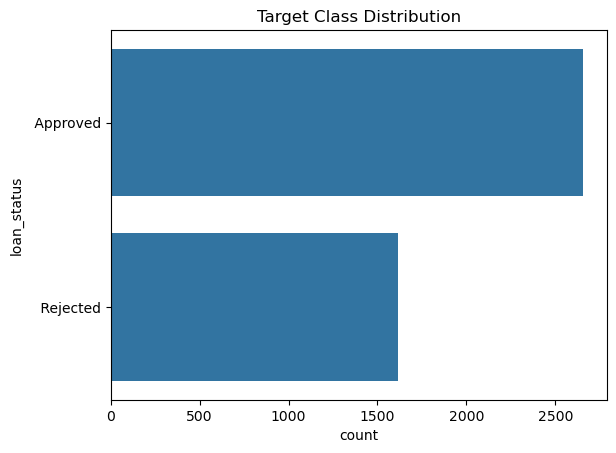

loan_status
Approved    0.622
Rejected    0.378
Name: proportion, dtype: float64

In [378]:
# Checking Target Class Distribution
sns.countplot(df.loan_status)
plt.title('Target Class Distribution')
plt.show()
df.loan_status.value_counts(normalize=True).round(3)

## 4. Exploratory Data Analysis 

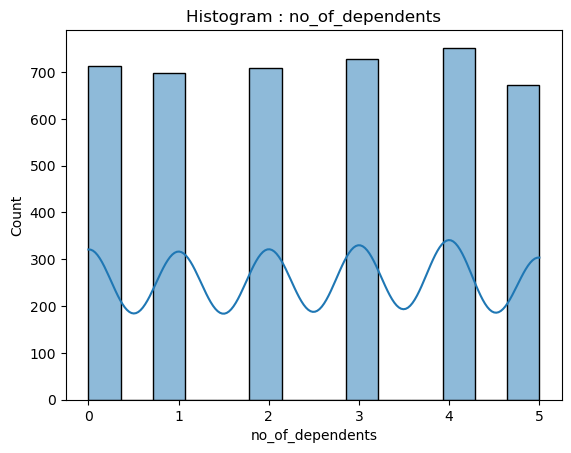

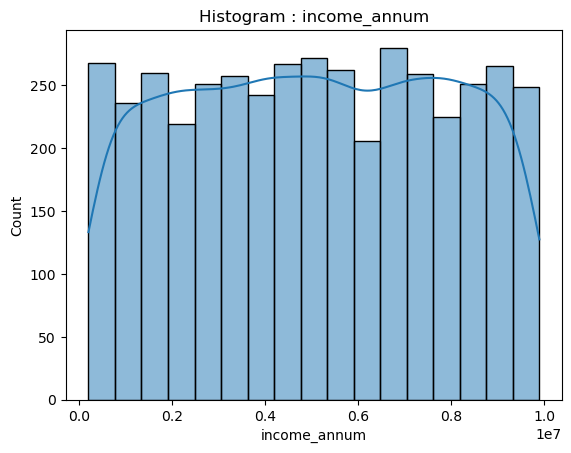

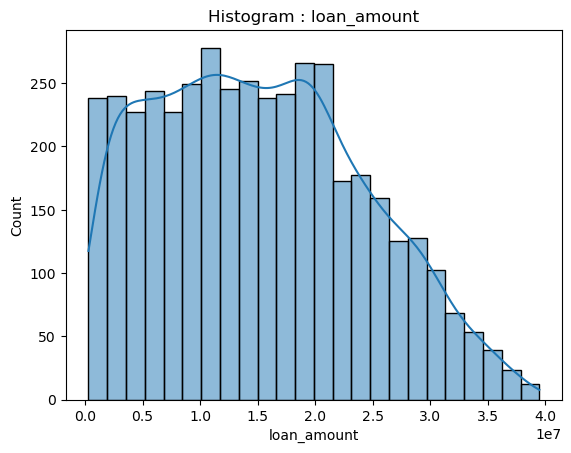

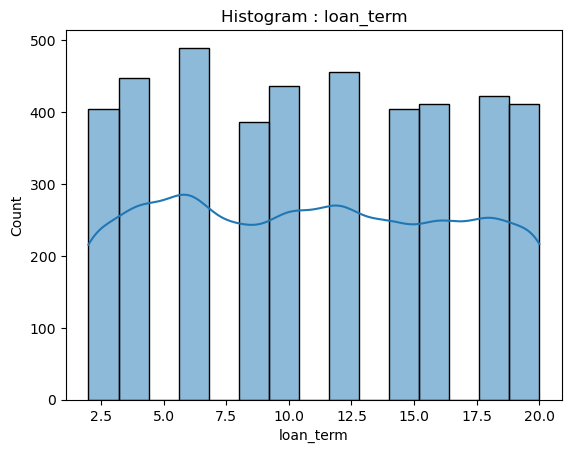

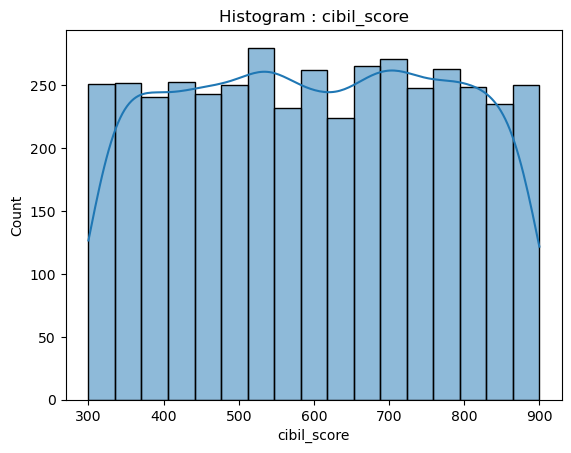

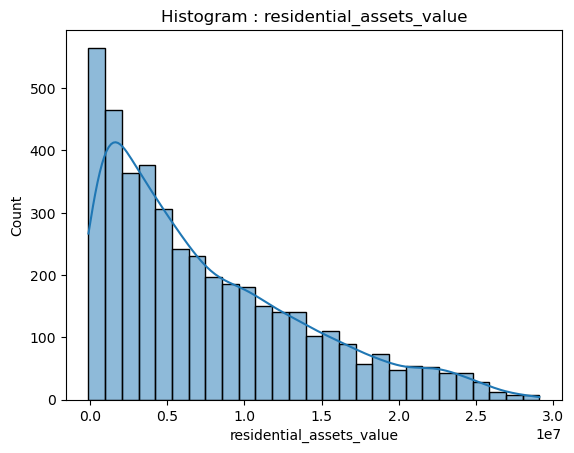

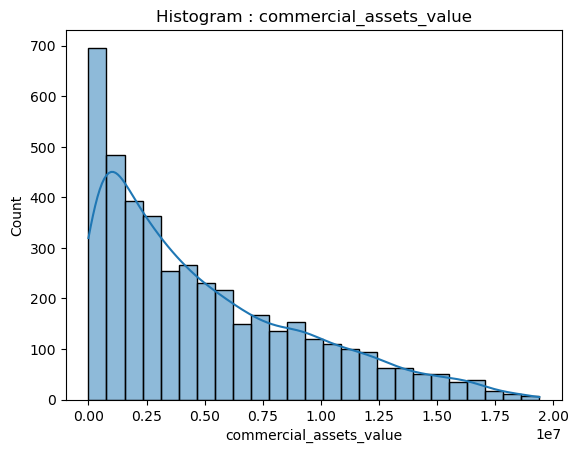

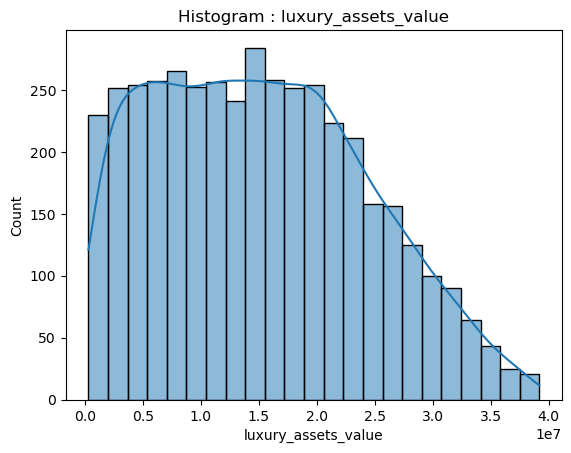

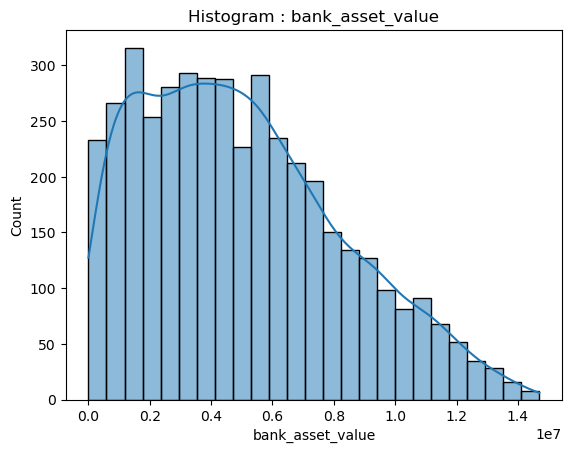

In [379]:
for cols in num_cols:
    sns.histplot(df[cols],kde=True)
    plt.title(f"Histogram : {cols}")
    plt.show()

In [380]:
df.bank_asset_value.skew(), df.commercial_assets_value.skew(), df.residential_assets_value.skew(), df.luxury_assets_value.skew()

(np.float64(0.5607250089736816),
 np.float64(0.9577908874986114),
 np.float64(0.9784505965115631),
 np.float64(0.3222075028955774))

Here we can see that, the asset vales are right skewed. So we take log value of these columns if the assets are relevent to the `loan_status`. If not then we take only total assets value by adding all the assets values and drop other assets value column.

In [381]:
df['Total_asset_value'] = df.residential_assets_value + df.commercial_assets_value + df.luxury_assets_value + df.bank_asset_value

In [382]:
df.Total_asset_value.skew()

np.float64(0.29724139686139023)

### Univariate Analysis

For Numerical Columns

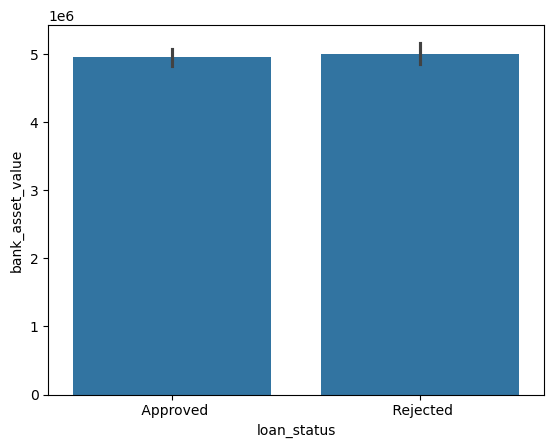

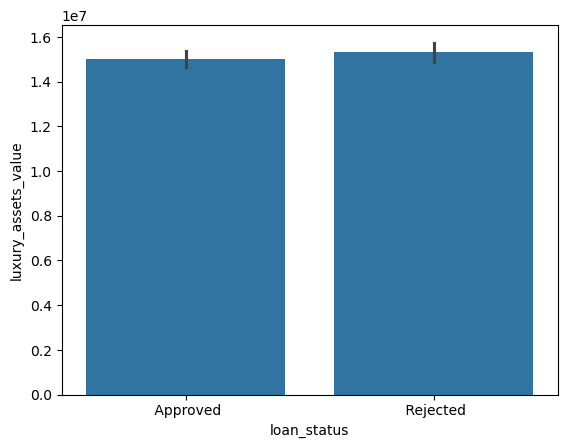

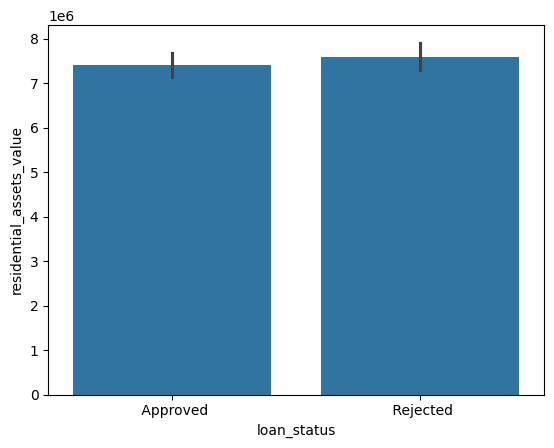

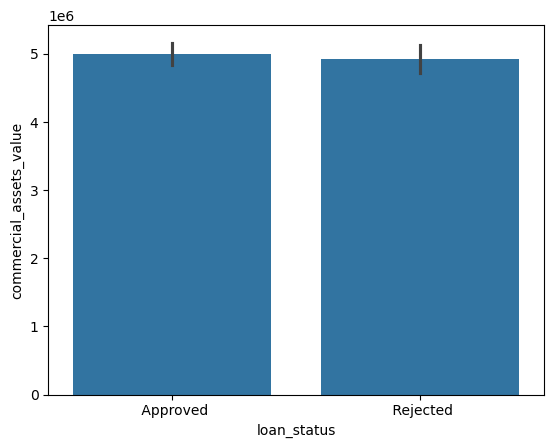

In [383]:
sns.barplot(x=df.loan_status,y=df.bank_asset_value)
plt.show()
sns.barplot(x=df.loan_status,y=df.luxury_assets_value)
plt.show()
sns.barplot(x=df.loan_status,y=df.residential_assets_value)
plt.show()
sns.barplot(x=df.loan_status,y=df.commercial_assets_value)
plt.show()

Since, none of the asssets value have meaningfull relation with `loan_status` individually, we will drop those column and keep only the total asset value as it is(without taking its log value since it is only mildly right skewed).

In [384]:
df.sample(2)

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,Total_asset_value
1378,1,Graduate,Yes,7900000,29200000,2,663,19600000,12100000,28600000,10100000,Approved,70400000
2002,3,Graduate,No,5500000,19800000,14,853,7300000,3000000,15500000,3100000,Approved,28900000


In [385]:
df = df.drop(columns=['bank_asset_value','luxury_assets_value','residential_assets_value','commercial_assets_value'])
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,loan_status,Total_asset_value
0,2,Graduate,No,9600000,29900000,12,778,Approved,50700000
1,0,Not Graduate,Yes,4100000,12200000,8,417,Rejected,17000000
2,3,Graduate,No,9100000,29700000,20,506,Rejected,57700000
3,3,Graduate,No,8200000,30700000,8,467,Rejected,52700000
4,5,Not Graduate,Yes,9800000,24200000,20,382,Rejected,55000000


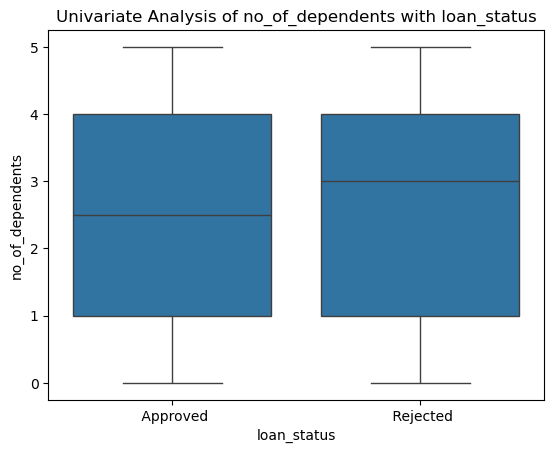

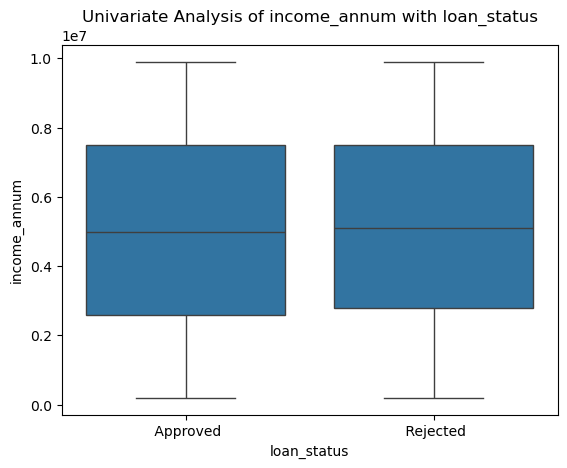

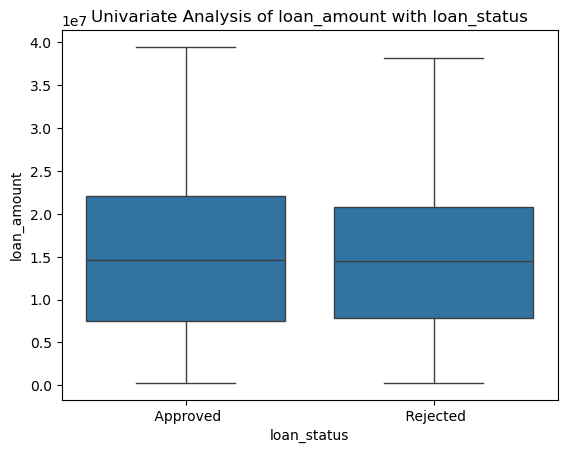

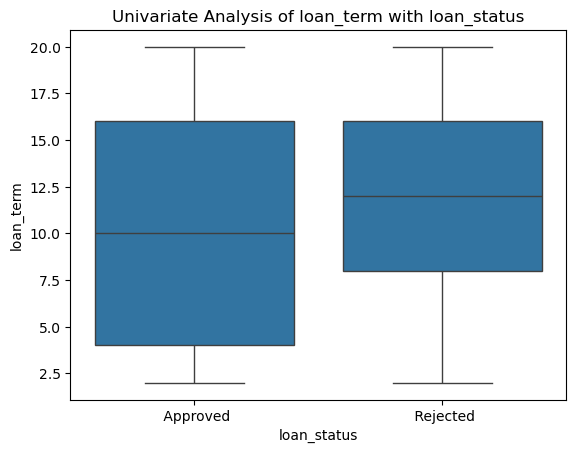

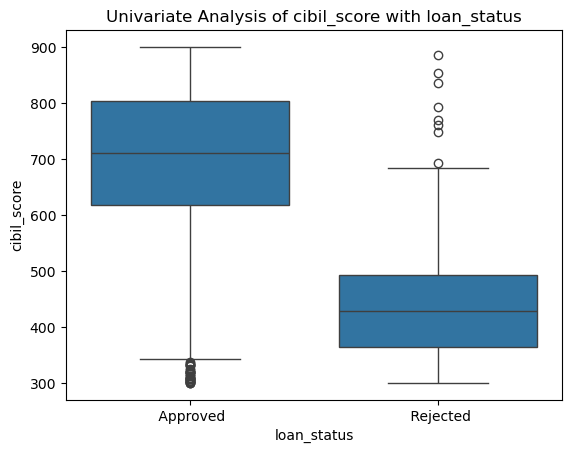

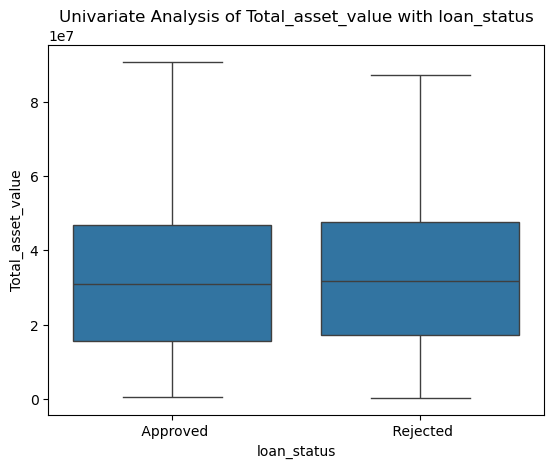

In [386]:
check = ['no_of_dependents','income_annum','loan_amount','loan_term','cibil_score','Total_asset_value']
for col in check:
    sns.boxplot(x=df.loan_status,y=df[col])
    plt.title(f'Univariate Analysis of {col} with loan_status')
    plt.show()

Here we can see that `cibil_score` is highly influencial on `loan_status`.

For Catagorical data

<Axes: xlabel='education', ylabel='count'>

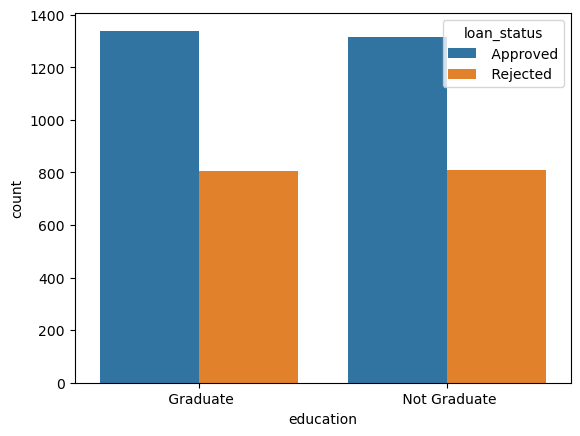

In [387]:
sns.countplot(x=df.education,hue=df.loan_status)

<Axes: xlabel='self_employed', ylabel='count'>

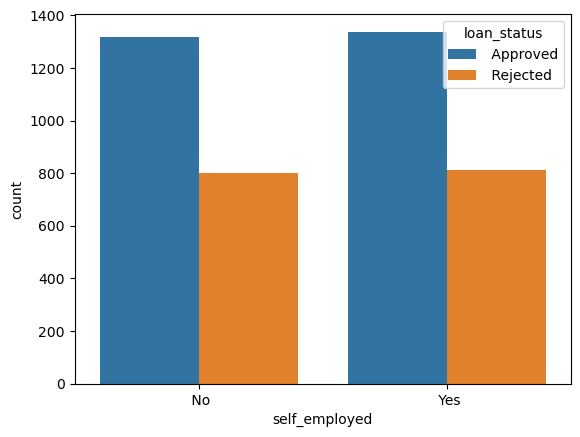

In [388]:
sns.countplot(x=df.self_employed,hue=df.loan_status)

### Multivariate Analysis

<Axes: >

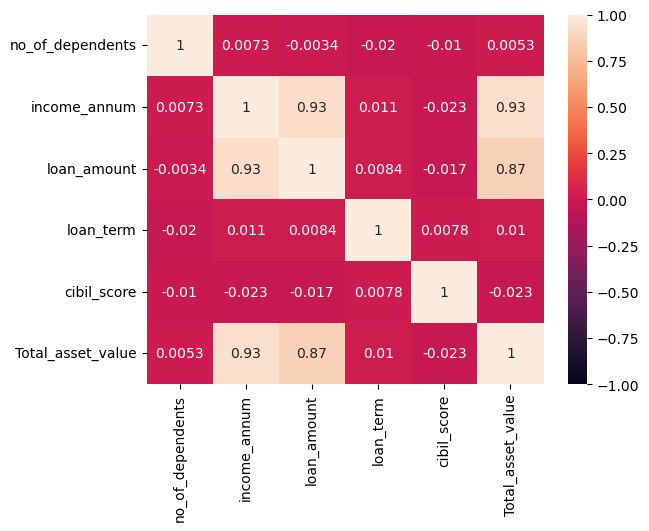

In [389]:
corr = df.select_dtypes(exclude=['object']).corr()
sns.heatmap(corr,annot=True,vmin=-1,vmax=1)

Here we can see `loan_amount`, `income_annum` and `Total_asset_value` are highly correlated to eachother.

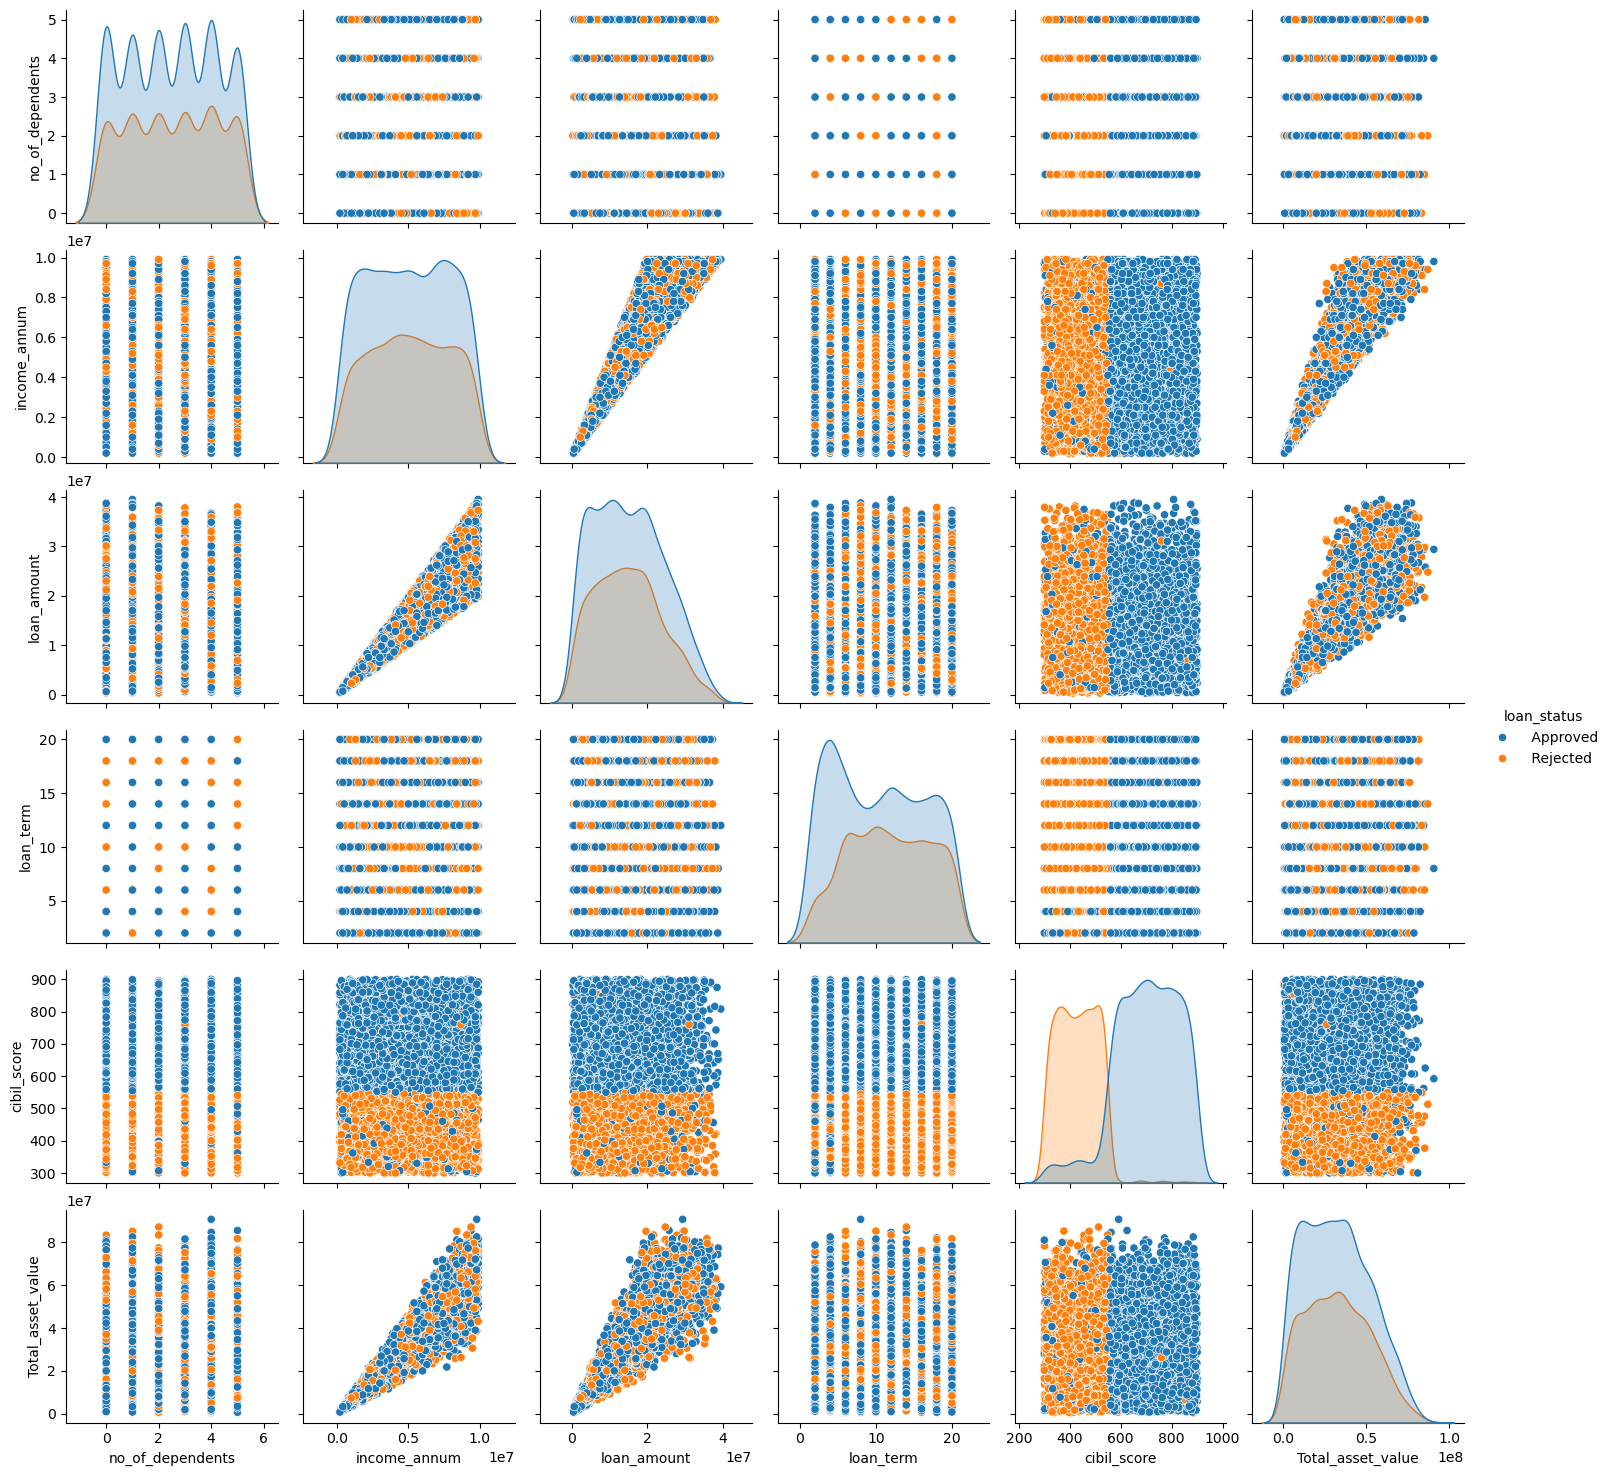

In [390]:
sns.pairplot(df,vars=check,hue='loan_status')

**This pair plot further confirms:**
- `cibil_score` is highly influencial on `loan_status` (Target Column).
- `Total_asset_value` , `income_annum`, and `loan_amount` are **Correlated** to eachother.

**EDA takeaways :**
- No missing values, so imputation is not needed.
- Target classes are somewhat imbalanced (~62% approved, 38% rejected).
- `cibil score` feature is strongly correlated with the target.


## 5. Preprocessing

In [391]:
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,loan_status,Total_asset_value
0,2,Graduate,No,9600000,29900000,12,778,Approved,50700000
1,0,Not Graduate,Yes,4100000,12200000,8,417,Rejected,17000000
2,3,Graduate,No,9100000,29700000,20,506,Rejected,57700000
3,3,Graduate,No,8200000,30700000,8,467,Rejected,52700000
4,5,Not Graduate,Yes,9800000,24200000,20,382,Rejected,55000000


In [392]:
X = df.drop('loan_status',axis=1)
y = df.loan_status
X.shape,y.shape

((4269, 8), (4269,))

In [393]:
xtrain, xtest, ytrain, ytest = train_test_split(X,y,test_size=0.25,random_state=42)
scaling_cols = X.select_dtypes(exclude=['object']).columns
encoding_cols = X.select_dtypes(include=['object']).columns
le = LabelEncoder()
scaler = StandardScaler()
ohe = OneHotEncoder(drop='first')
scaling_cols,encoding_cols

(Index(['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term',
        'cibil_score', 'Total_asset_value'],
       dtype='object'),
 Index(['education', 'self_employed'], dtype='object'))

In [394]:
ytrain = le.fit_transform(ytrain)
ytest = le.transform(ytest)

In [395]:
xtrain.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,Total_asset_value
3977,5,Graduate,Yes,7600000,18000000,12,452,40700000
2425,0,Not Graduate,No,6000000,22900000,16,302,43500000
1545,2,Not Graduate,Yes,8200000,27800000,16,827,56900000
173,2,Not Graduate,Yes,7400000,28200000,8,376,49500000
3405,1,Graduate,Yes,3400000,7000000,4,534,21700000


In [396]:
preprocessor = ColumnTransformer([
    ('StandardScaler',scaler,scaling_cols),
    ('OneHotEncoder',ohe,encoding_cols)
], remainder='passthrough')
xtrain = preprocessor.fit_transform(xtrain)
xtest = preprocessor.transform(xtest)

## 6. Training Classification Models

In [397]:
models = {
    'KNeighborsClassifier':KNeighborsClassifier(),
    'DecisionTreeClassifier':DecisionTreeClassifier(),
    'RandomForestClassifier':RandomForestClassifier(),
    'XGBClassifier':XGBClassifier(),
    'LogisticRegression':LogisticRegression(),
    'SVC':SVC()
}

In [398]:
def check_score(y_pred_test,y_test,y_pred_train,y_train):
    acctest = accuracy_score(y_test,y_pred_test)
    acctrain = accuracy_score(y_train,y_pred_train)
    rectest = recall_score(y_test,y_pred_test)
    rectrain = recall_score(y_train,y_pred_train)
    pretest = precision_score(y_test,y_pred_test)
    pretrain = precision_score(y_train,y_pred_train)
    roctest = roc_auc_score(y_test,y_pred_test)
    roctrain = roc_auc_score(y_train,y_pred_train)
    f1test = f1_score(y_test,y_pred_test)
    f1train = f1_score(y_train,y_pred_train)
    return acctest,acctrain,rectest,rectrain,pretest,pretrain,roctest,roctrain,f1test,f1train

In [399]:
res = []
for name,mod in models.items():
    model = mod
    model.fit(xtrain,ytrain)
    ytest_pred = model.predict(xtest)
    ytrain_pred = model.predict(xtrain)
    acctest,acctrain,rectest,rectrain,pretest,pretrain,roctest,roctrain,f1test,f1train = check_score(ytest_pred,ytest,ytrain_pred,ytrain)
    res.append({
                'Model Name':name,
                'Model':model,
                'Accuracy Test':acctest,
                'Accuracy Train':acctrain,
                'Recall Test':rectest,
                'Recall Train':rectrain,
                'Precision Test':pretest,
                'Precision Train':pretrain,
                'ROC AUC Test':roctest,
                'ROC AUC Train':roctrain,
                'F1 Score Test':f1test,
                'F1 Score Train':f1train
            })
    print(f"{name} Model Trained Sucessfully.")

KNeighborsClassifier Model Trained Sucessfully.
DecisionTreeClassifier Model Trained Sucessfully.
RandomForestClassifier Model Trained Sucessfully.
XGBClassifier Model Trained Sucessfully.
LogisticRegression Model Trained Sucessfully.
SVC Model Trained Sucessfully.


## 7. Comparing the Models based on Performance Metrices

In [ ]:
result = pd.DataFrame(res).sort_values(by='F1 Score Test',ascending=False).reset_index(drop=True)
result_df = result.drop('Model',axis=1)
result_df 

,Model Name,Accuracy Test,Accuracy Train,Recall Test,Recall Train,Precision Test,Precision Train,ROC AUC Test,ROC AUC Train,F1 Score Test,F1 Score Train
0,XGBClassifier,0.987828,1.000000,0.976923,1.000000,0.989610,1.000000,0.985512,1.000000,0.983226,1.000000
1,RandomForestClassifier,0.985955,1.000000,0.976923,1.000000,0.984496,1.000000,0.984037,1.000000,0.980695,1.000000
2,DecisionTreeClassifier,0.985019,1.000000,0.976923,1.000000,0.981959,1.000000,0.983299,1.000000,0.979434,1.000000
3,SVC,0.941948,0.959388,0.923077,0.954211,0.918367,0.940371,0.937940,0.958400,0.920716,0.947240
4,KNeighborsClassifier,0.923221,0.955014,0.928205,0.946852,0.870192,0.936136,0.924280,0.953456,0.898263,0.941463
5,LogisticRegression,0.903558,0.920025,0.856410,0.896975,0.876640,0.894051,0.893544,0.915626,0.866407,0.895510


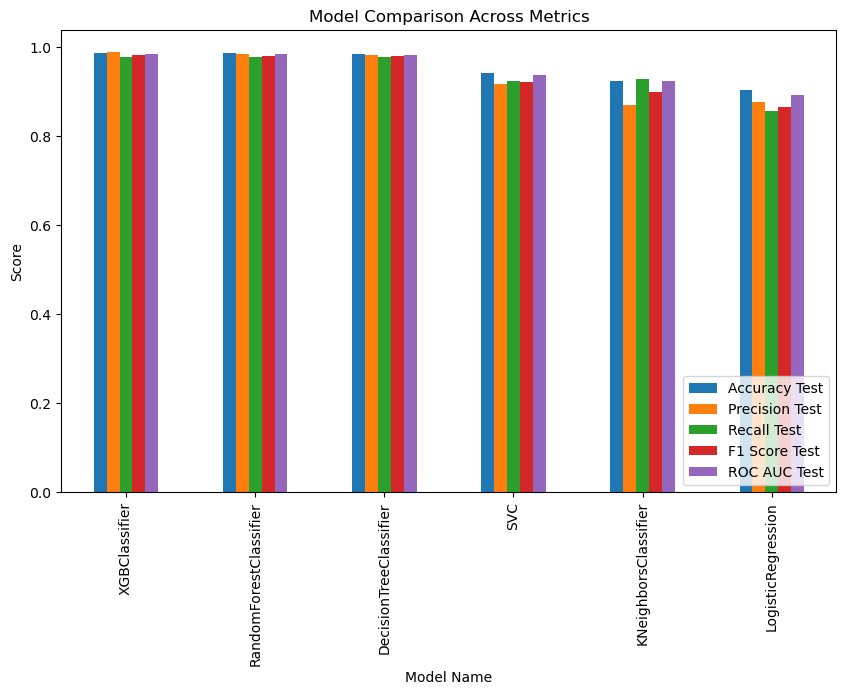

In [401]:
# Visual comparision of Metrices
result.set_index("Model Name")[["Accuracy Test", "Precision Test", "Recall Test", "F1 Score Test", "ROC AUC Test"]].plot(
    kind='bar', figsize=(10, 6)
)
plt.title("Model Comparison Across Metrics")
plt.ylabel("Score")
plt.xticks(rotation=90)
plt.legend(loc='lower right')
plt.show()

## 8. Select and Justify the Best Model

**Selection Logic :** Looking at the comparison table above, the **XGBoost** model typically achieves the highest `F1-score` and `ROC-AUC Score` among all the models.

In [402]:
best_model_name = result_df.iloc[0]["Model Name"]
best_model = result.iloc[0]['Model']
print(f"Best Model : {best_model_name}")

Best Model : XGBClassifier


## 9. Hyper-parameter Tuning

In [404]:
param = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}
tuner = GridSearchCV(best_model,param_grid=param)

In [405]:
tuner.fit(xtrain,ytrain)

,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'subsample': [0.8, 1.0]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'binary:logistic'


In [406]:
tuner.best_params_

{'colsample_bytree': 0.8,
 'learning_rate': 0.1,
 'max_depth': 7,
 'subsample': 0.8}

In [407]:
xgb = XGBClassifier(colsample_bytree = 0.8, learning_rate=0.1, max_depth=7, subsample = 0.8)

In [409]:
xgb.fit(xtrain,ytrain)
ybest_test_pred = xgb.predict(xtest)
ybest_train_pred = xgb.predict(xtrain)
print(f"Test : {f1_score(ytest,ybest_test_pred)}")
print(f"Train : {f1_score(ytrain,ybest_train_pred)}")

Test : 0.9831824062095731
Train : 0.9975409836065574


In [410]:
print(classification_report(ytest,ybest_test_pred, target_names=['Accepted','Rejected']))

              precision    recall  f1-score   support

    Accepted       0.99      1.00      0.99       678
    Rejected       0.99      0.97      0.98       390

    accuracy                           0.99      1068
   macro avg       0.99      0.98      0.99      1068
weighted avg       0.99      0.99      0.99      1068



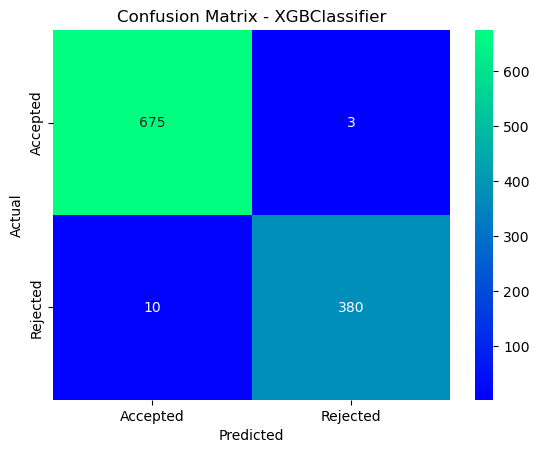

In [413]:
cm = confusion_matrix(ytest,ybest_test_pred)
sns.heatmap(cm,annot=True,cmap='winter',fmt='d',yticklabels=['Accepted','Rejected'],xticklabels=['Accepted','Rejected'])
plt.title('Confusion Matrix - XGBClassifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [416]:
# Important Features
xtrain = pd.DataFrame(xtrain,columns=preprocessor.get_feature_names_out())
pd.DataFrame({'Features':xtrain.columns,
              'Importance':xgb.feature_importances_
              }).sort_values(by='Importance',ascending=False)

,Features,Importance
4,StandardScaler__cibil_score,0.722659
3,StandardScaler__loan_term,0.171312
2,StandardScaler__loan_amount,0.025479
1,StandardScaler__income_annum,0.023982
5,StandardScaler__Total_asset_value,0.019337
0,StandardScaler__no_of_dependents,0.013747
6,OneHotEncoder__education_ Not Graduate,0.012045
7,OneHotEncoder__self_employed_ Yes,0.011440


`Cibil_score` is the most important feature.

## 10. Testing on Unseen Data

In [ ]:
unseendata = xtrain.sample(5)
predections = xgb.predict(unseendata)
probs = xgb.predict_proba(unseendata)[:,0] 
results_unseen = unseendata.copy()
results_unseen['Predicted_Class'] = np.where(predections == 0, 'Accepted', 'Rejected')
results_unseen['Probablity (Accepted)'] = probs.round(3)
results_unseen[['Predicted_Class','Probablity (Accepted)']]

,Predicted_Class,Probablity (Accepted)
3125,Rejected,0.092
1491,Accepted,0.998
23,Accepted,0.955
1209,Rejected,0.002
1159,Accepted,0.999


## 11. Conclusion

- Trained and compared 6 classification Models.
- Used Hyper parameter tuning on the best performing model.
- Gained imformation about Important Features.
- The selected model was used to predict on Unseen data.